### CMPS 6790 Final Project - Kyle Parfait - kparfait17.github.io

### Milestone 2

For my project, I am working with two datasets related to students' academic performance, study habits, and lifestyle. These datasets include a lot of information that would be valuable for analysis, like GPA, GPA history, daily study hours, and stress levels.

As someone with educators in my family, I am personally curious to explore what factors attribute to this decline. Many cite lack of parental support, too much social media usage, poor mental health, and relying on AI to complete work without comprehending concepts. 
        
> Can GPA be predicted using lifestyle factors such as study hours, sleep, and stress level?
A linear regression model was used to predict GPA using lifestyle variables including study hours, sleep, and stress level. This model tests whether daily habits significantly influence academic performance.

> Can GPA be predicted using academic and institutional factors such as study time, attendance, and credits completed?
A second linear regression model was constructed using academic variables such as study time, attendance, and credits completed. This model evaluates how institutional and academic factors relate to GPA.

Data Sources
- https://www.kaggle.com/datasets/charlottebennett1234/lifestyle-factors-and-their-impact-on-students
- https://data.mendeley.com/datasets/dc3797vf3t/1/files/57b43a3a-a060-4247-afd9-cc17dfbf87f7



In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [141]:
# Dataset - Student Academic Performance
student_df = pd.read_csv("../data/student_performance_dataset.csv")

# Additional Dataset - Student Lifestyle Dataset
lifestyle_df = pd.read_csv("../data/student_lifestyle_dataset.csv")

# Clean attendance_rate (convert to numeric)
student_df["attendance_rate"] = pd.to_numeric(
    student_df["attendance_rate"],
    errors="coerce"
)

# Dropping columns not useful for analysis
student_df = student_df.drop(columns=["university_admission_year", "age", "hs_grad_year"])
lifestyle_df = lifestyle_df.drop(columns=["Student_ID"])

In [142]:
student_df.dtypes

gender                            object
program                           object
current_semester                   int64
scholarship                       object
university_transport              object
daily_study_hours                  int64
seated_study_hours                 int64
learning_mode_preference          object
smart_phone_usage                 object
personal_computer                 object
social_media_hours                 int64
english_skills                    object
attendance_rate                  float64
probation                         object
suspension                        object
tutoring                          object
skills                            object
skill_development_daily_hours      int64
interested_area                   object
relationship_status               object
extracurriculars                  object
living_situation                  object
health_issues                     object
previous_gpa                     float64
physical_disabil

In [143]:
lifestyle_df.dtypes

Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                                float64
Stress_Level                        object
dtype: object

In [144]:
# There are quite a bit of columns that could give some very good information about academic performance.
student_df.columns.tolist()

['gender',
 'program',
 'current_semester',
 'scholarship',
 'university_transport',
 'daily_study_hours',
 'seated_study_hours',
 'learning_mode_preference',
 'smart_phone_usage',
 'personal_computer',
 'social_media_hours',
 'english_skills',
 'attendance_rate',
 'probation',
 'suspension',
 'tutoring',
 'skills',
 'skill_development_daily_hours',
 'interested_area',
 'relationship_status',
 'extracurriculars',
 'living_situation',
 'health_issues',
 'previous_gpa',
 'physical_disabilities',
 'gpa',
 'credits_completed',
 'family_income']

In [145]:
# The lifestyle dataset includes additional information that could give insights into students' mental health.
lifestyle_df.columns.to_list() 

['Study_Hours_Per_Day',
 'Extracurricular_Hours_Per_Day',
 'Sleep_Hours_Per_Day',
 'Social_Hours_Per_Day',
 'Physical_Activity_Hours_Per_Day',
 'GPA',
 'Stress_Level']

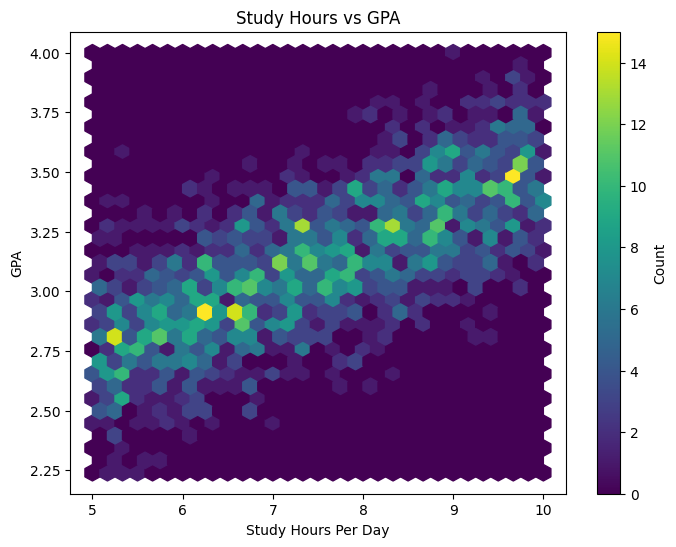

In [146]:
# Hexbin for daily study hours and GPA
plt.figure(figsize=(8, 6))

plt.hexbin(
    lifestyle_df["Study_Hours_Per_Day"],
    lifestyle_df["GPA"],
    gridsize=30
)

plt.colorbar(label="Count")
plt.xlabel("Study Hours Per Day")
plt.ylabel("GPA")
plt.title("Study Hours vs GPA")

plt.show()

> This hexbin plot shows the relationship between study hours and GPA. The higher density of observations at higher study hours and GPA values suggests a positive relationship, which aligns with the correlation and regression results.

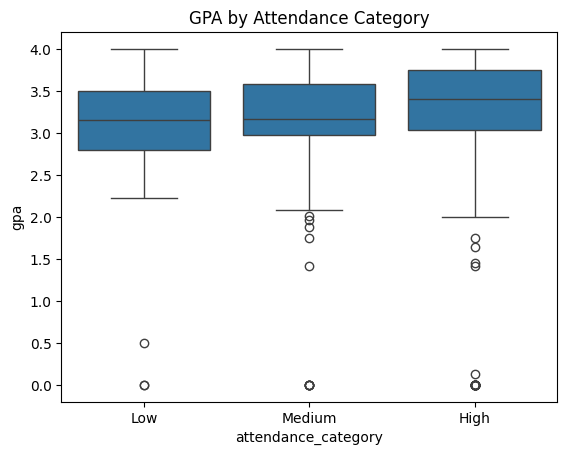

In [147]:
student_df["attendance_category"] = pd.cut(
    student_df["attendance_rate"],
    bins=[0, 80, 90, 100],
    labels=["Low", "Medium", "High"]
)

sns.boxplot(data=student_df, x="attendance_category", y="gpa")
plt.title("GPA by Attendance Category")
plt.show()

> This boxplot shows that there is a slightly positive relationship with attendance rates and GPA.

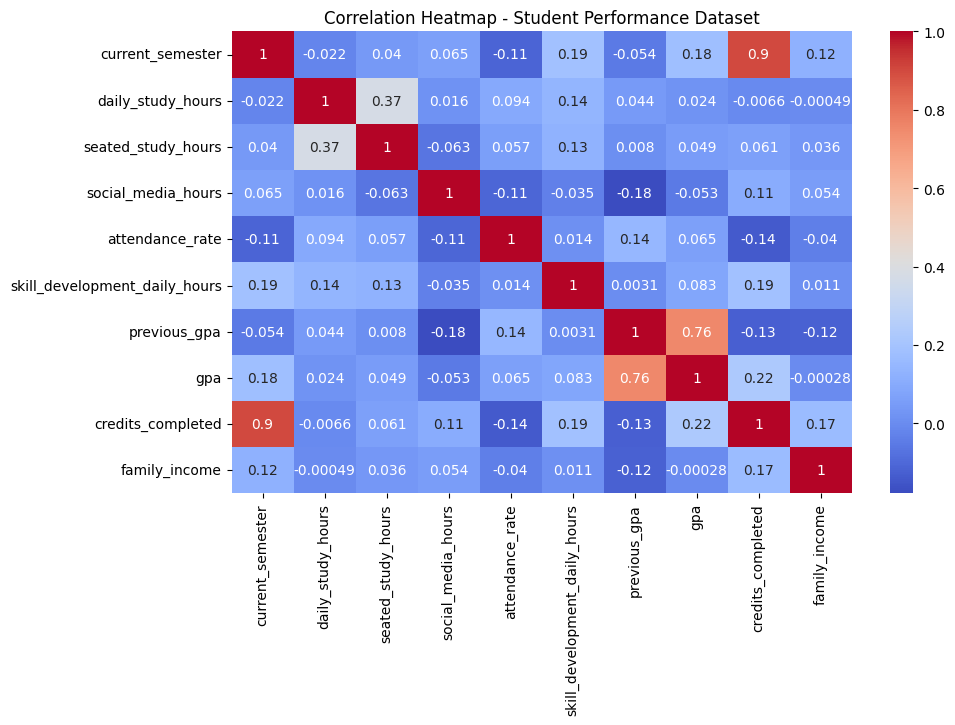

In [148]:
plt.figure(figsize=(10, 6))
sns.heatmap(student_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Student Performance Dataset")
plt.show()

> This heatmap shows the correlation between variables in the student performance dataset. The strongest relationship with GPA is the previous semester's GPA (appx. 0.76), indicating that past academic performance is the best predictor of current GPA. Credits completed also show a slight positive relationship with GPA (appx. 0.22), suggesting that degree program progression might contribute to performance.

> Overall, the heatmap suggests that structural and historical academic factors are more influential than daily behaviors in predicting GPA in this dataset.

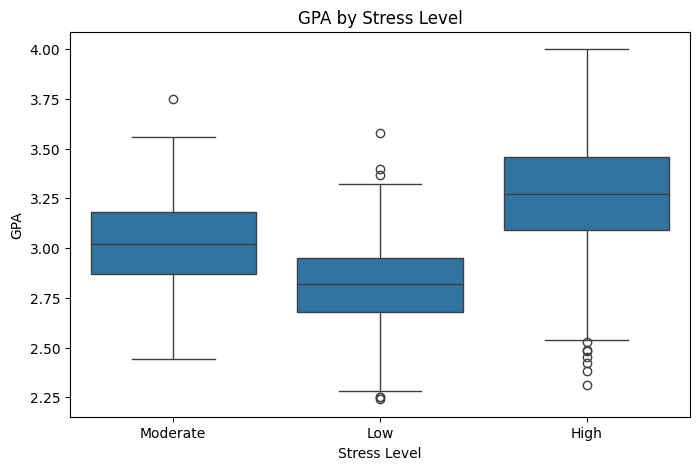

Stress_Level
High        3.261973
Low         2.816869
Moderate    3.024837
Name: GPA, dtype: float64

In [159]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=lifestyle_df, x="Stress_Level", y="GPA")
plt.title("GPA by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("GPA")
plt.show()

lifestyle_df["Sleep_Category"] = pd.cut(
    lifestyle_df["Sleep_Hours_Per_Day"],
    bins=[0, 5, 7, 10],
    labels=["Low", "Medium", "High"]
)

lifestyle_df.groupby("Stress_Level")["GPA"].mean()

> From this visualization, one can see that students with slightly higher GPAs (3.26 mean) report a higher level of stress. Students with slightly lower GPA (2.81 mean) report lower stress levels.

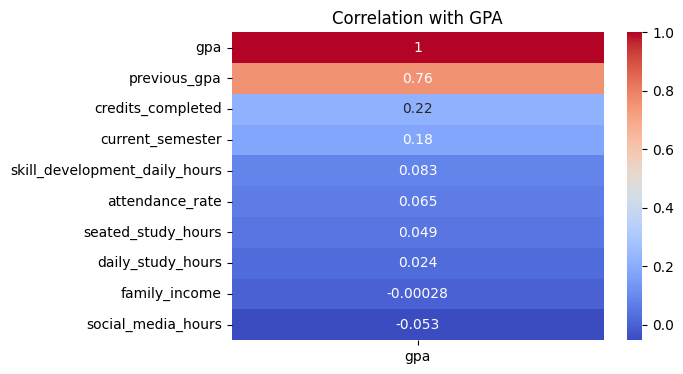

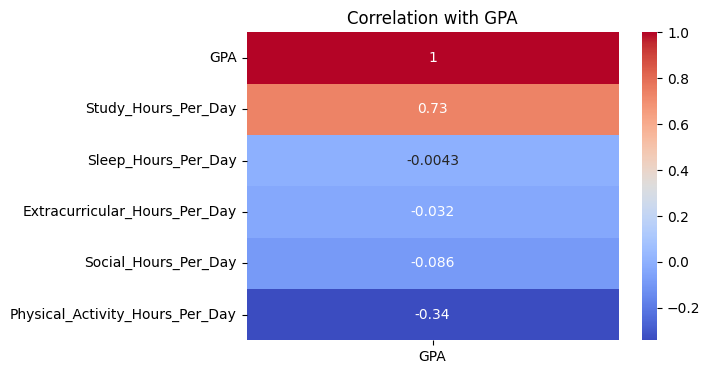

In [151]:
# These two heatmaps show the variables that have the strongest relationship with GPA.
correlation = student_df.corr(numeric_only=True)["gpa"].sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with GPA")
plt.show()

correlation = lifestyle_df.corr(numeric_only=True)["GPA"].sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with GPA")
plt.show()

> The correlation results differ across the two datasets. In the academic-focused dataset, study hours show little relationship with GPA, while previous semester GPA is the strongest predictor. In contrast, the lifestyle-focused dataset shows a strong positive relationship between study hours and GPA. This suggests that the importance of study time may depend on the context of the data and that prior academic performance can overpower behavioral factors.

#### Model 1: Lifestyle Factors and GPA

Question:
- Can GPA be predicted using lifestyle factors such as study hours, sleep, and stress level?

Dependent Variable:
- GPA

Independent Variables:
- Study_Hours_Per_Day
- Sleep_Hours_Per_Day
- Stress_Level_Num

Methodology:
- I used a linear regression model to estimate how lifestyle behaviors influence GPA.

In [ ]:
lifestyle_model_df = lifestyle_df.copy()

stress_map = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

lifestyle_model_df["Stress_Level_Num"] = lifestyle_model_df["Stress_Level"].map(stress_map)

X = lifestyle_model_df[
    ["Study_Hours_Per_Day", "Sleep_Hours_Per_Day", "Stress_Level_Num"]
]
y = lifestyle_model_df["GPA"]

model1 = LinearRegression()
model1.fit(X, y)

# Adding polynomial regression model to capture potential nonlinear relationships
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(
    lifestyle_model_df[["Study_Hours_Per_Day", "Sleep_Hours_Per_Day", "Stress_Level_Num"]]
)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

print("Intercept:", model1.intercept_)
print("Coefficients:", model1.coef_)
print("R^2:", model1.score(X, y))
print("R^2 (Polynomial):", model_poly.score(X_poly, y))

Intercept: 1.9998110518512138
Coefficients: [ 1.54143675e-01 -4.86835083e-03  1.35408994e-04]
R^2: 0.5400149395331738
R^2 (Polynomial): 0.5425051977972364


#### Model 1 Interpretation

The linear regression results show how each lifestyle variable contributes to GPA. Study hours have a positive relationship with GPA, while stress level has a slight negative effect. Sleep shows minimal impact in this model.

The R² value of approximately 0.54 indicates that about 54% of the variation in GPA can be explained by these lifestyle variables.

A polynomial regression model was also tested to capture potential nonlinear relationships, particularly for variables such as sleep. But, the R² value only increased slightly (from appx. 0.5400 to 0.5425), indicating that adding nonlinear terms does not really improve the model.

These results align with the EDA findings, where study hours showed a strong positive correlation with GPA and stress level showed a negative relationship. Overall, this suggests that the relationship between lifestyle factors and GPA is largely linear, and lifestyle variables can be meaningful predictors of academic performance.

#### Model 2: Academic Factors and GPA

Question:
Can GPA be predicted using academic and institutional factors such as study time, attendance, and credits completed?

Dependent Variable:
- gpa

Independent Variables:
- daily_study_hours
- attendance_rate
- social_media_hours
- credits_completed

Methodology:
I used another linear regression model is used to evaluate how academic factors relate to GPA.

In [153]:
student_model_df = student_df.copy()

# There was one value in the attendance_rate column that wasn't a simple integer, it was "94-98".
# I'm making sure the column is converted to numeric values, then dropping the offending row.
student_model_df["attendance_rate"] = pd.to_numeric(
    student_model_df["attendance_rate"],
    errors="coerce"
)

student_model_df = student_model_df.dropna(
    subset=["attendance_rate", "daily_study_hours", "social_media_hours", "credits_completed", "gpa"]
)

X2 = student_model_df[["daily_study_hours", "attendance_rate", "social_media_hours", "credits_completed"]]
y2 = student_model_df["gpa"]

model2 = LinearRegression()
model2.fit(X2, y2)

print("Intercept:", model2.intercept_)
print("Coefficients:", model2.coef_)
print("R^2:", model2.score(X2, y2))

Intercept: 2.5601509810027654
Coefficients: [ 0.00819391  0.0043469  -0.02271053  0.00377095]
R^2: 0.06349237758186688


#### Model 2 Interpretation

The regression results show that previous academic performance and structural factors play a significant role in predicting GPA. The coefficients indicate the direction and magnitude of each variable’s effect.

The R² value reflects how well these academic variables explain GPA compared to the lifestyle model.

The EDA results showed that daily study hours had a weak relationship with GPA in this dataset, while other structural factors were more influential. This suggests that academic performance may depend more on prior achievement and institutional factors than daily behavior alone.

#### Final Model Comparison

The two models demonstrate that predictors of GPA vary depending on the dataset. The lifestyle model shows strong relationships between study behavior and GPA, while the academic model suggests that prior performance and structural factors are more influential. This highlights that academic success is influenced by both behavior and context, and that different datasets can lead to different conclusions.

In [154]:
lifestyle_df.describe()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


In [155]:
student_df.describe()

,current_semester,daily_study_hours,seated_study_hours,social_media_hours,attendance_rate,skill_development_daily_hours,previous_gpa,gpa,credits_completed,family_income
count,1194.000000,1194.000000,1194.000000,1194.000000,1193.000000,1194.000000,1194.000000,1194.000000,1194.000000,1.194000e+03
mean,6.539363,3.131491,1.940536,3.289782,88.251467,2.185092,2.683945,3.165603,71.842546,6.248812e+04
std,3.809884,1.649597,0.856305,2.289547,15.319105,1.296101,0.871592,0.750132,48.074338,7.617356e+04
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+03
25%,3.000000,2.000000,1.000000,2.000000,80.000000,1.000000,2.200000,2.900000,23.000000,3.000000e+04
50%,7.000000,3.000000,2.000000,3.000000,93.000000,2.000000,2.680000,3.210000,78.000000,5.000000e+04
75%,10.000000,4.000000,2.000000,4.000000,100.000000,3.000000,3.380000,3.670000,117.000000,7.400000e+04
max,24.000000,13.000000,7.000000,20.000000,100.000000,12.000000,4.000000,4.000000,145.000000,2.000000e+06
